In [1]:
#esercizio 1

C:\Users\aless\AppData\Local\Temp\ipykernel_21752\2517012821.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


[np.float64(0.43266899247946), np.float64(1.9156331475013937), np.float64(2.1068604877859682)]


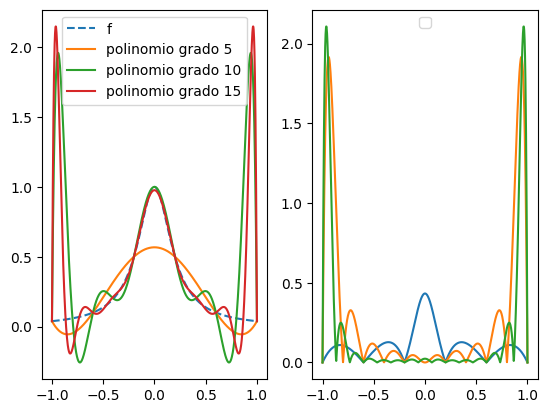

In [13]:
import numpy as np
from numpy import polyfit, polyval
import matplotlib.pyplot as plt

N=np.array([5,10,15])
f=lambda x:1/(1+25*x**2)
err=[]
a=-1
b=1
xx=np.linspace(a, b, 1000)
plt.subplot(1,2,1)
plt.plot(xx, f(xx), '--', label='f')
for n in N:
    x_grid=np.linspace(a,b,n+1)
    p=polyfit(x_grid, f(x_grid), n)
    y=lambda x: polyval(p,x)

    err_dis=np.abs(y(xx)-f(xx))
    err.append(np.max(err_dis))
    plt.subplot(1,2,1)
    plt.plot(xx, y(xx), label='polinomio grado %d' %n)
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(xx, err_dis)
    plt.legend()
print(err)



[np.float64(0.6386170635191082), np.float64(0.132194852951123), np.float64(0.09930812463776229)]


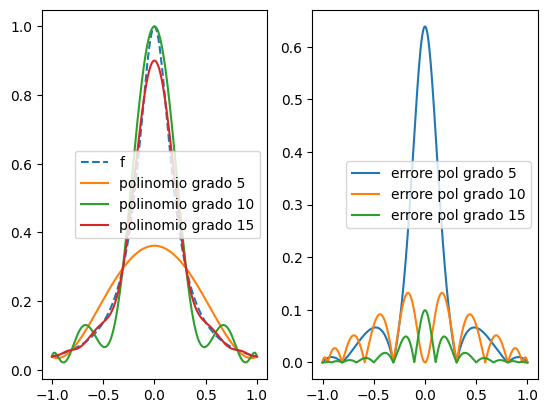

In [19]:

err=[]
xx=np.linspace(a,b, 1000)
plt.subplot(1,2,1)
plt.plot(xx, f(xx), '--', label='f')
for n in N:
    xi=np.zeros(n+1)
    for i in range(n+1):
        theta_i=-np.cos(np.pi/(n)*i)
        xi[i]=(a+b)/2+(b-a)/2*theta_i
    p=polyfit(xi, f(xi), n)
    y=lambda x: polyval(p, x)

    err_dis=(np.abs(f(xx)-y(xx)))
    err.append(max(err_dis))

    plt.subplot(1,2,1)
    plt.plot(xx, y(xx), label='polinomio grado %d' %n)
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(xx, err_dis, label='errore pol grado %d' %n)
    plt.legend()

print(err)



    



In [20]:
#esercizio 2

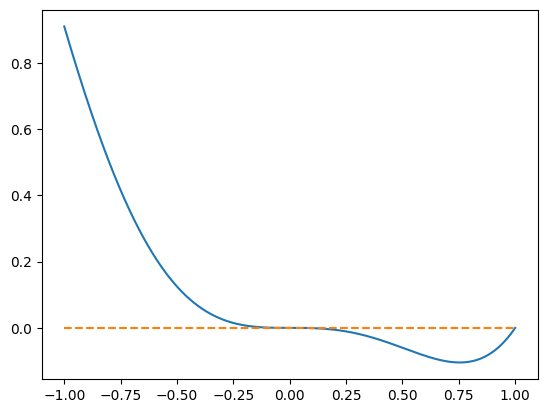

In [22]:
f=lambda x: x**3*np.sin(x-1)
a=-1
b=1

x_grid=np.linspace(a,b, 1000)
plt.plot(x_grid, f(x_grid))
plt.plot(x_grid, np.zeros_like(x_grid), '--')

9.275658632119685e-09


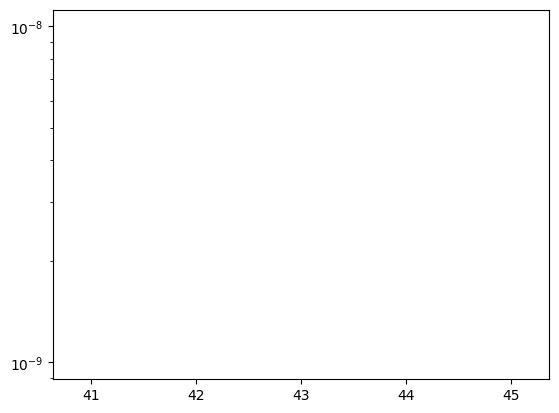

In [27]:
x0=0.5
toll=1e-8
x_ex=0
x_old=x0
df=lambda x: 3*x**2*np.sin(x-1)+x**3*np.cos(x-1)
err=toll+1
niter=0
while err>toll:
    x_new=x_old-f(x_old)/df(x_old)
    err=np.abs(x_new-x_ex)
    x_old=x_new
    niter+=1

print(x_new)
plt.semilogy(niter,err)

In [28]:
#esercizio 3

In [31]:
#dt_max=h/f'max=h/3
h=0.125
dt_max=h/3
print(dt_max)

0.041666666666666664


In [39]:
help(fv_solve)

Help on function fv_solve in module utilis_solver_cl:

fv_solve(u0, f, df, L, T, h, dt, flux_function)
    Risolve un problema di trasporto con legge di conservazione usando il metodo ai volumi finiti 1D.

    Il metodo ai volumi finiti è una tecnica robusta per la risoluzione di equazioni
    di conservazione: l'intervallo spaziale viene suddiviso in celle e si discretizzano
    i flussi alle interfacce tra celle.

    Equazione: ∂u/∂t + ∂f(u)/∂x = 0
    Discretizzazione: u_i^{n+1} = u_i^n - (dt/h) * (F_{i+1/2}^n - F_{i-1/2}^n)

    Input:
        u0 (callable): Dato iniziale - funzione u(x) al tempo t=0
        f (callable): Funzione di flusso f(u)
        df (callable): Derivata del flusso f'(u)
        L (float): Lunghezza dell'intervallo spaziale [0, L]
        T (float): Tempo finale di integrazione
        h (float): Larghezza delle celle spaziali
        dt (float): Passo temporale
        flux_function (callable): Funzione per il calcolo del flusso numerico
                   

In [41]:
def upwind_flux(f,df,uL,uR):
  """
  Input:
    f  (lambda function)
    df (lambda function)
    uL (numpy.ndarray)
    uR (numpy.ndarray)
    Output:
    F (numpy.ndarray)
  """
  F=[]
  for i in range (len(uL)):
    #verifica della monotonia del flusso
    if (df(uL[i])*df(uR[i])<0):
      raise RuntimeError ('il metrodo upwind non si può applicare')
    else: 
      if (df(uL[i])>=0):
        F.append(f(uL[i]))
      else:
        F.append(f(uR[i]))
  return np.array(F)

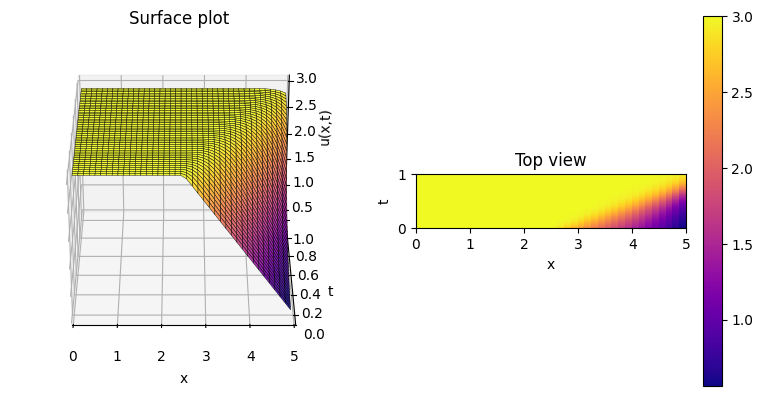

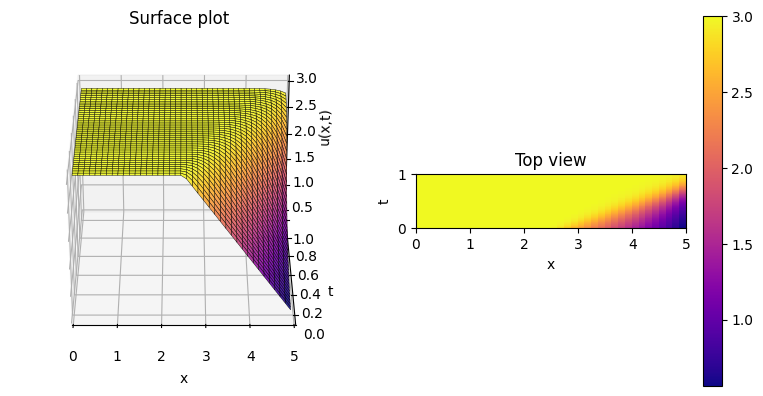

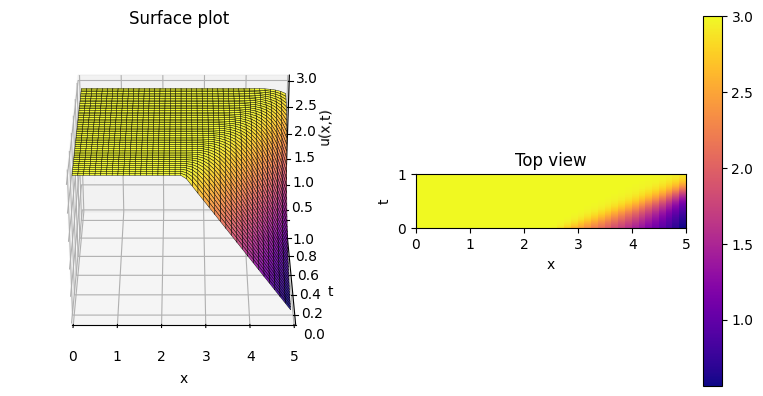

In [45]:
from utilis_plot_cl import*
from utilis_solver_cl import*
L=5
T=1
N=T/dt_max
Nt=np.array([N,N-2,2*N])
u0=lambda x: 3*(x<=2.5) + (5.5-x)*(x>2.5)
f=lambda x:0.5*x**2
df=lambda x: x


for n in Nt:
    dt=h/n
    xc,t,u=fv_solve(u0, f, df,L, T, h, dt, flux_function=upwind_flux)
    xtplot(xc, t, u, 'surface')
    

In [46]:
def godunov_flux(f,df, uL, uR):
    """
    Calcola il flusso di Godunov generico:
    - f: funzione di flusso 
    - df: derivata del flusso (in questo caso muta)
    - uL, uR: array sinistra e destra delle celle
    """
    N = len(uL)
    F = np.zeros(N) 

    for i in range(N):
        ul = uL[i]
        ur = uR[i]

        if ul == ur:
            F[i] = f(ul)
        else:
            u_min, u_max = min(ul, ur), max(ul, ur)
            u_sample = np.linspace(u_min, u_max, 1000)
            f_sample = f(u_sample)
            if ul < ur:
                F[i] = np.min(f_sample)
            else:
                F[i] = np.max(f_sample)
    return F


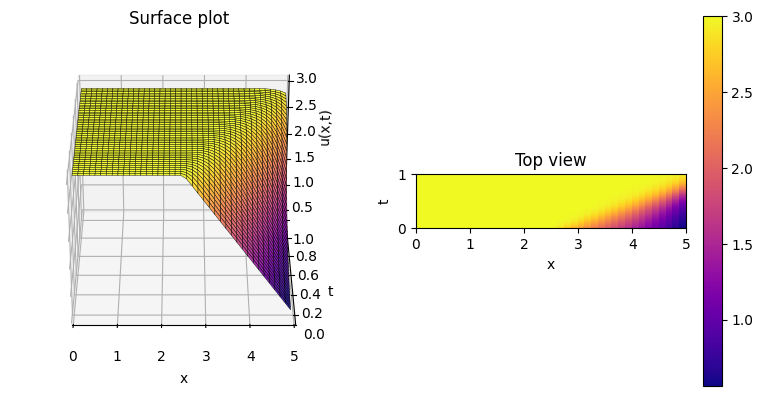

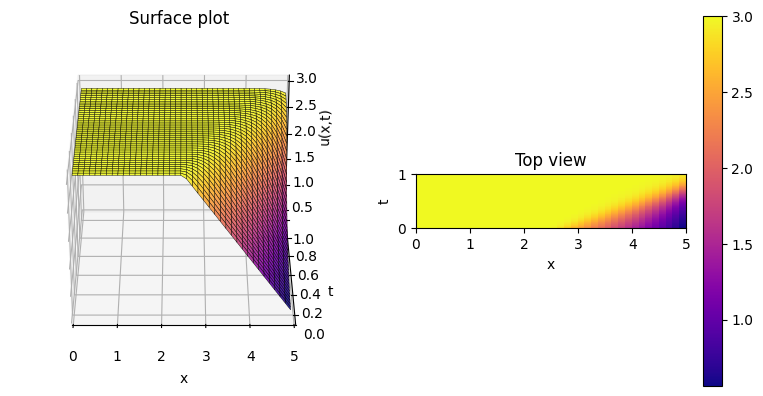

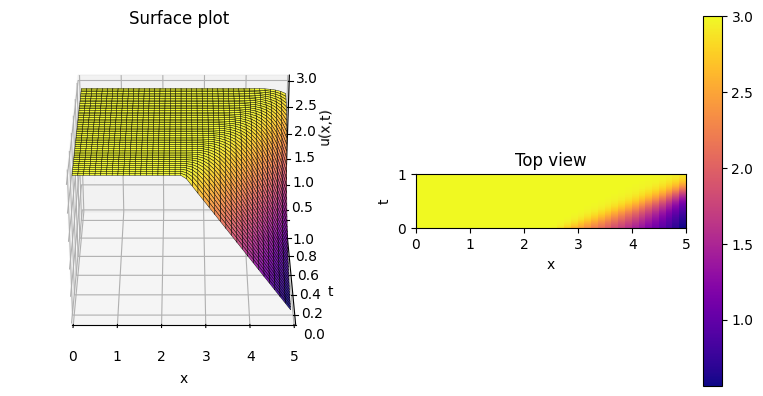

In [47]:
for n in Nt:
    dt=h/n
    xc,t,u=fv_solve(u0, f, df,L, T, h, dt, flux_function=godunov_flux)
    xtplot(xc, t, u, 'surface')